
# Shor AQFT phase-distribution notebook

Este notebook **não sintetiza o circuito modular completo do Shor**.
Ele simula a **distribuição do registrador de fase** usando as autofases
\(j/r\) do problema de order-finding e aplica uma **AQFT truncada** com
parâmetro `m`.

Parâmetros ajustáveis:
- `N`: número a fatorar
- `L`: número de qubits do registrador de fase
- `m`: truncamento da AQFT
- `a`: base opcional coprima com `N`

Esta versão foi ajustada para funcionar também com **16 bits** e, em geral,
com valores maiores, desde que `L` permaneça administrável.


In [1]:

%pip -q install numpy matplotlib qiskit



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:

import math
import random
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


In [2]:

def is_prime(n: int) -> bool:
    if n < 2:
        return False
    if n % 2 == 0:
        return n == 2
    d = 3
    while d * d <= n:
        if n % d == 0:
            return False
        d += 2
    return True


def multiplicative_order(a: int, N: int) -> int:
    if math.gcd(a, N) != 1:
        raise ValueError("a e N precisam ser coprimos.")
    x = 1
    for r in range(1, N + 1):
        x = (x * a) % N
        if x == 1:
            return r
    raise RuntimeError("Não foi possível encontrar a ordem.")


def try_factor_from_order(a: int, N: int, r: int):
    if r % 2 != 0:
        return None
    x = pow(a, r // 2, N)
    if x == N - 1:
        return None
    p = math.gcd(x - 1, N)
    q = math.gcd(x + 1, N)
    if 1 < p < N:
        return (p, N // p)
    if 1 < q < N:
        return (q, N // q)
    return None


def bit_reverse(x: int, nbits: int) -> int:
    out = 0
    for _ in range(nbits):
        out = (out << 1) | (x & 1)
        x >>= 1
    return out


In [3]:

def aqft_dagger(L: int, m: int) -> QuantumCircuit:
    """
    AQFT inversa truncada em L qubits.
    Mantém apenas rotações controladas até distância m.
    Para m >= L, coincide com a IQFT usual (sem swaps explícitos, mas com
    correção de bit-reversal na leitura).
    """
    qc = QuantumCircuit(L, name=f"AQFT†(L={L},m={m})")

    # Implementação padrão da IQFT sem swaps finais
    for j in range(L):
        # rotações controladas truncadas
        start_k = max(0, j - m + 1)
        for k in range(start_k, j):
            angle = -np.pi / (2 ** (j - k))
            qc.cp(angle, k, j)
        qc.h(j)

    return qc


def pre_iqft_state_for_phase(phi: float, L: int) -> Statevector:
    """
    Estado do registrador de fase após phase kickback e antes da IQFT/AQFT:
    (1/sqrt(2^L)) sum_x exp(2πi phi x) |x>
    """
    M = 2 ** L
    amps = np.exp(2j * np.pi * phi * np.arange(M)) / np.sqrt(M)
    return Statevector(amps)


def aqft_distribution_for_phase(phi: float, L: int, m: int) -> np.ndarray:
    """
    Aplica AQFT† ao estado de fase e devolve as probabilidades finais.
    Corrige a convenção de leitura com bit-reversal.
    """
    qc = aqft_dagger(L, m)
    sv = pre_iqft_state_for_phase(phi, L).evolve(qc)
    probs = sv.probabilities()

    # Corrige a ausência de swaps explícitos
    reordered = np.zeros_like(probs)
    for y, p in enumerate(probs):
        reordered[bit_reverse(y, L)] = p
    return reordered


In [4]:

def ideal_shor_phase_distribution_from_order(r: int, L: int, m: int) -> np.ndarray:
    """
    Distribuição final do registrador de fase no order-finding do Shor:
    média uniforme sobre as autofases phi = j/r, j=0,...,r-1.
    """
    M = 2 ** L
    probs = np.zeros(M, dtype=float)
    for j in range(r):
        phi = j / r
        probs += aqft_distribution_for_phase(phi, L, m)
    probs /= r
    probs /= probs.sum()
    return probs


def choose_good_a(N: int, max_a_tries: int = 100, seed: int = 1234):
    rng = random.Random(seed)
    pool = list(range(2, N))
    rng.shuffle(pool)

    best = None
    best_r = None
    best_factors = None

    for cand in pool[:max_a_tries]:
        g = math.gcd(cand, N)
        if 1 < g < N:
            return cand, None, (g, N // g)

        if g != 1:
            continue

        r = multiplicative_order(cand, N)
        fac = try_factor_from_order(cand, N, r)

        if best is None:
            best, best_r = cand, r
        if fac is not None:
            return cand, r, fac

    return best, best_r, best_factors


In [5]:
def top_phase_peaks(probs: np.ndarray, L: int, max_den: int, top_k: int = 20):
    M = len(probs)
    idx = np.argsort(probs)[::-1][:top_k]
    rows = []
    for y in idx:
        frac = Fraction(int(y), M).limit_denominator(max_den)
        rows.append({
            "y": int(y),
            "bitstring": format(int(y), f"0{L}b"),
            "phase_estimate": y / M,
            "probability": float(probs[y]),
            "continued_fraction": f"{frac.numerator}/{frac.denominator}",
        })
    rows.sort(key=lambda row: row["probability"], reverse=True)
    return rows


def show_peaks(rows, max_rows=None):
    if rows is None:
        print("Sem picos para mostrar.")
        return
    if max_rows is None:
        max_rows = len(rows)
    if len(rows) == 0:
        print("Lista de picos vazia.")
        return

    bit_width = max(8, max(len(r["bitstring"]) for r in rows))
    header = (
        f"{'rank':>4} {'y':>8} {'bitstring':>{bit_width}} "
        f"{'phase':>14} {'prob':>14} {'frac. cont.':>12}"
    )
    print(header)
    print("-" * len(header))
    for i, row in enumerate(rows[:max_rows], 1):
        print(
            f"{i:>4} {row['y']:>8} {row['bitstring']:>{bit_width}} "
            f"{row['phase_estimate']:>14.8f} {row['probability']:>14.8e} "
            f"{row['continued_fraction']:>12}"
        )


In [6]:

def shor_aqft_phase_distribution(
    N: int,
    m: int,
    L: int,
    a: int | None = None,
    max_a_tries: int = 100,
    seed: int = 1234,
    top_k: int = 400
):
    """
    Simula a distribuição de probabilidades do registrador de fase do Shor
    usando AQFT inversa truncada.

    Esta versão NÃO impõe mais o limite N < 512.
    O limite prático passa a ser tempo/memória, principalmente por causa de 2^L.
    """
    if N < 2:
        raise ValueError("Use N >= 2.")
    if L <= 0:
        raise ValueError("L deve ser positivo.")
    if m <= 0:
        raise ValueError("m deve ser positivo.")

    if N % 2 == 0:
        return {
            "status": "trivial_even",
            "N": N,
            "m": m,
            "L": L,
            "a": None,
            "order": None,
            "factors": (2, N // 2),
            "probs": None,
            "peaks": None,
        }

    if is_prime(N):
        return {
            "status": "prime",
            "N": N,
            "m": m,
            "L": L,
            "a": None,
            "order": None,
            "factors": None,
            "probs": None,
            "peaks": None,
        }

    if a is None:
        chosen_a, r, factors = choose_good_a(N, max_a_tries=max_a_tries, seed=seed)
        if chosen_a is None:
            raise RuntimeError("Não foi possível encontrar um valor adequado de a.")
        a = chosen_a
    else:
        g = math.gcd(a, N)
        if 1 < g < N:
            return {
                "status": "non_coprime_a",
                "N": N,
                "m": m,
                "L": L,
                "a": a,
                "order": None,
                "factors": (g, N // g),
                "probs": None,
                "peaks": None,
            }
        if g != 1:
            raise ValueError("a deve ser coprimo com N.")
        r = multiplicative_order(a, N)
        factors = try_factor_from_order(a, N, r)

    if 'r' not in locals() or r is None:
        r = multiplicative_order(a, N)

    probs = ideal_shor_phase_distribution_from_order(r, L, m)
    peaks = top_phase_peaks(probs, L=L, max_den=N, top_k=top_k)

    status = "success" if factors is not None else "order_found_but_no_factor"

    return {
        "status": status,
        "N": N,
        "m": m,
        "L": L,
        "a": a,
        "order": r,
        "factors": factors,
        "probs": probs,
        "peaks": peaks,
    }


In [7]:

def summarize_result(result):
    print("status :", result["status"])
    print("N      :", result["N"])
    print("m      :", result["m"])
    print("L      :", result["L"])
    print("a      :", result["a"])
    print("ordem  :", result["order"])
    print("fatores:", result["factors"])


def plot_phase_distribution(result, max_points=None):
    probs = result["probs"]
    if probs is None:
        print("Não há distribuição de fases para este caso.")
        return

    M = len(probs)
    xs = np.arange(M) / M

    if max_points is not None and max_points < M:
        idx = np.argsort(probs)[::-1][:max_points]
        idx = np.sort(idx)
        xs = xs[idx]
        probs = probs[idx]

    plt.figure(figsize=(12, 4))
    plt.bar(xs, probs, width=1 / M)
    plt.xlabel("Fase estimada y / 2^L")
    plt.ylabel("Probabilidade")
    plt.title(
        f"Distribuição AQFT das fases - N={result['N']}, a={result['a']}, r={result['order']}, L={result['L']}, m={result['m']}"
    )
    plt.tight_layout()
    plt.show()



## Exemplo de uso com 16 bits

Sugestões:
- começar com `L = 16`
- testar `m = 3, 4, 5, 6`
- se quiser algo mais próximo da IQFT exata, usar `m >= L`


status : success
N      : 10403
m      : 13
L      : 14
a      : 8761
ordem  : 5100
fatores: (103, 101)
rank        y      bitstring          phase           prob  frac. cont.
-----------------------------------------------------------------------
   1        0 00000000000000     0.00000000 1.99258327e-04          0/1
   2    13653 11010101010101     0.83331299 1.95103234e-04    6829/8195
   3    10922 10101010101010     0.66662598 1.95103221e-04    5461/8192
   4     5461 01010101010101     0.33331299 1.83091035e-04   3467/10402
   5     6826 01101010101010     0.41662598 1.83091035e-04    3413/8192
   6    16383 11111111111111     0.99993896 1.64519170e-04  10402/10403
   7     8192 10000000000000     0.50000000 1.64518687e-04          1/2
   8      127 00000001111111     0.00775146 1.45692047e-04     80/10321
   9       64 00000001000000     0.00390625 1.45692047e-04        1/256
  10       63 00000000111111     0.00384521 1.44652617e-04      16/4161
  11       32 00000000100000    

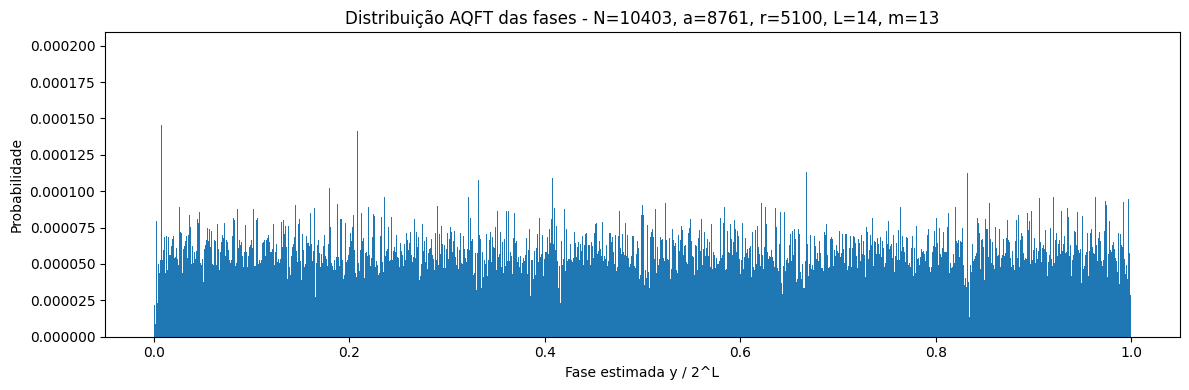

In [13]:

N = 10403   # exemplo =<16 bits
m = 13       # truncamento da AQFT
L = 14      # número de qubits do registrador de fase
a = None    # None = escolhe automaticamente; ou fixe um coprimo com N

result = shor_aqft_phase_distribution(N=N, m=m, L=L, a=a, top_k=400)
summarize_result(result)

if result["peaks"] is not None:
    show_peaks(result["peaks"], max_rows=400)
    plot_phase_distribution(result, max_points=16384)


{'status': 'success', 'N': 10403, 'm': 5, 'L': 14, 'a': 8761, 'order': 5100, 'factors': (103, 101), 'probs': array([1.99258327e-04, 1.49607658e-05, 1.49607658e-05, ...,
       3.18205639e-05, 2.34367854e-05, 1.56251133e-04], shape=(16384,)), 'peaks': [{'y': 0, 'bitstring': '00000000000000', 'phase_estimate': np.float64(0.0), 'probability': 0.0001992583274841434, 'continued_fraction': '0/1'}, {'y': 13653, 'bitstring': '11010101010101', 'phase_estimate': np.float64(0.83331298828125), 'probability': 0.0001920100862911902, 'continued_fraction': '6829/8195'}, {'y': 10922, 'bitstring': '10101010101010', 'phase_estimate': np.float64(0.6666259765625), 'probability': 0.00019166308773645318, 'continued_fraction': '5461/8192'}, {'y': 6826, 'bitstring': '01101010101010', 'phase_estimate': np.float64(0.4166259765625), 'probability': 0.00018056113803294944, 'continued_fraction': '3413/8192'}, {'y': 5461, 'bitstring': '01010101010101', 'phase_estimate': np.float64(0.33331298828125), 'probability': 0.

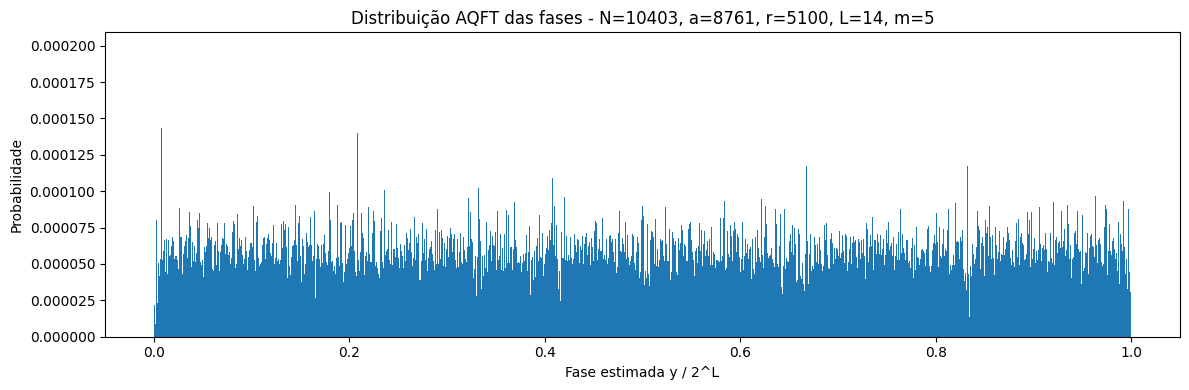

In [12]:
print(result)
print(result["probs"])
print (len(result["probs"]))
plot_phase_distribution(result, max_points=16384)


## Mais alguns números de 16 bits para estudar

- `47053 = 211 × 223`
- `50621 = 223 × 227`
- `51983 = 227 × 229`

Você pode substituir `N` e comparar o efeito de `m` e `L`.
